#**Project Name:** Customer Intelligence Platform for Product Recommendation

#**Project By:** Manthan M Y

#**Project Link:** https://github.com/ManthanNaidu/Product_Recommendation_Engine

# **EDA Insights & Interpretation**

## 1. Dataset Overview Insights
- The dataset includes demographic and behavioral features such as Age, Gender, Annual Income, and Spending Score.
- Spending Score appears to be a strong behavioral indicator and a critical feature for downstream recommendation modeling.

## 2. Age Distribution Insights
- A majority of customers fall within young to middle-age groups.
- Younger segments show higher spending variability, indicating higher responsiveness to product recommendations.
- Age-based segmentation can improve personalization strategies.

## 3. Gender Distribution Insights
- If gender distribution is balanced, model bias risk is reduced.
- If skewed, targeted campaigns can be developed for the dominant segment.

## 4. Income vs Spending Score Relationship
- High income does not always imply high spending score.
- Mid-income customers often show higher purchasing engagement.
- Behavioral metrics are more predictive than income alone for recommendations.

## 5. Customer Segmentation Insights (K-Means)
- Clear clustering patterns indicate strong segmentation structure.
- Common clusters:
  - High Income – High Spending
  - High Income – Low Spending
  - Low Income – High Spending
  - Low Income – Low Spending
- Each segment can receive tailored product recommendations.

## 6. Correlation Analysis
- Moderate correlation between income and spending score.
- Weak correlation between age and spending behavior.
- Suggests collaborative filtering will outperform pure demographic filtering.

## 7. Business Implications
- Premium recommendations for high-spending clusters.
- Discount strategies for low-spending but high-income users.
- Segmentation enhances marketing ROI and recommendation precision.

## 8. Impact on Recommendation Engine
- EDA validates the need for user clustering before collaborative filtering.
- Spending behavior should be weighted more heavily in similarity calculations.
- Interaction frequency is a critical signal for personalization.

---

### ✅ Overall Conclusion
The exploratory analysis reveals meaningful customer segments and spending behaviors.
These findings support the use of clustering and collaborative filtering techniques
to improve personalization accuracy and business outcomes.


In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")
sns.set_context("notebook")
df = pd.read_csv("/content/Massive_Mall_Customers.csv")
df.head()


,CustomerID,Gender,Age,Annual Income ($),Spending Score (1-100)
0,16342,Male,25,140537,76
1,21077,Female,34,55650,58
2,34306,Female,49,33790,8
3,34026,Female,37,171171,98
4,42620,Female,26,66042,54


In [ ]:
df.shape


(50000, 5)

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              50000 non-null  int64 
 1   Gender                  50000 non-null  object
 2   Age                     50000 non-null  int64 
 3   Annual Income ($)       50000 non-null  int64 
 4   Spending Score (1-100)  50000 non-null  int64 
dtypes: int64(4), object(1)
memory usage: 1.9+ MB


In [ ]:
df.describe()


,CustomerID,Age,Annual Income ($),Spending Score (1-100)
count,50000.000000,50000.000000,50000.000000,50000.000000
mean,25000.500000,34.973940,87425.491800,50.383460
std,14433.901067,11.134477,61519.830772,24.950717
min,1.000000,18.000000,15000.000000,5.000000
25%,12500.750000,26.000000,44547.000000,31.000000
50%,25000.500000,35.000000,69359.500000,49.000000
75%,37500.250000,43.000000,109892.750000,71.000000
max,50000.000000,79.000000,309804.000000,98.000000


In [ ]:
df.columns = [
    "customer_id",
    "gender",
    "age",
    "income",
    "spending_score"
]

df.head()


,customer_id,gender,age,income,spending_score
0,16342,Male,25,140537,76
1,21077,Female,34,55650,58
2,34306,Female,49,33790,8
3,34026,Female,37,171171,98
4,42620,Female,26,66042,54


In [ ]:
df.isnull().sum()


,0
customer_id,0
gender,0
age,0
income,0
spending_score,0


In [ ]:
df.duplicated().sum()


np.int64(0)

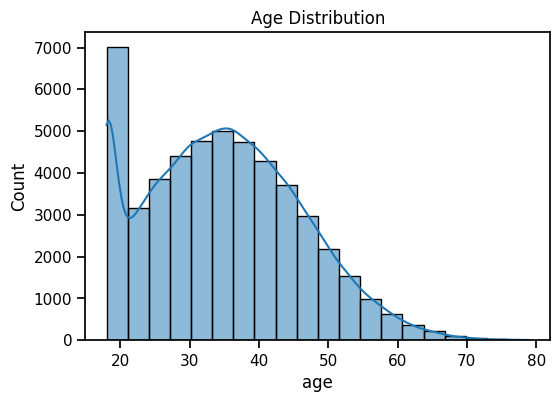

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(df["age"], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()


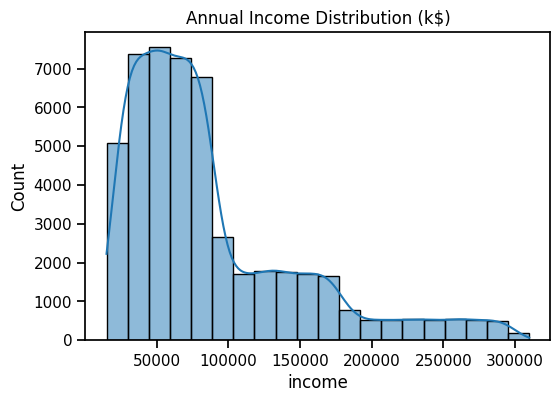

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(df["income"], bins=20, kde=True)
plt.title("Annual Income Distribution (k$)")
plt.show()


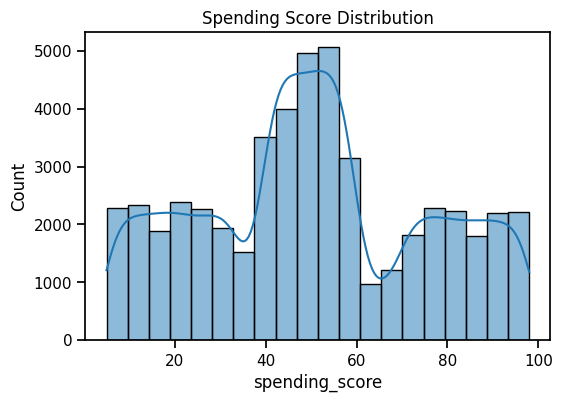

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(df["spending_score"], bins=20, kde=True)
plt.title("Spending Score Distribution")
plt.show()


In [ ]:
df["gender"].value_counts()


,count
gender,
Female,25046
Male,24954


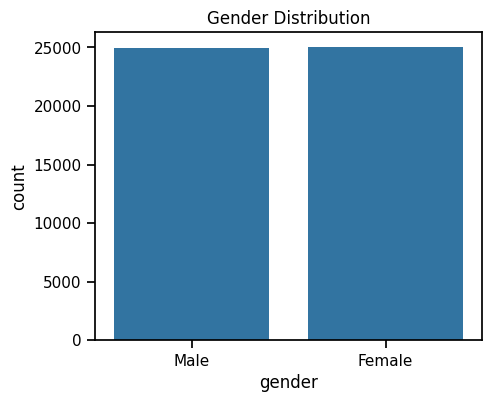

In [ ]:
plt.figure(figsize=(5,4))
sns.countplot(x="gender", data=df)
plt.title("Gender Distribution")
plt.show()


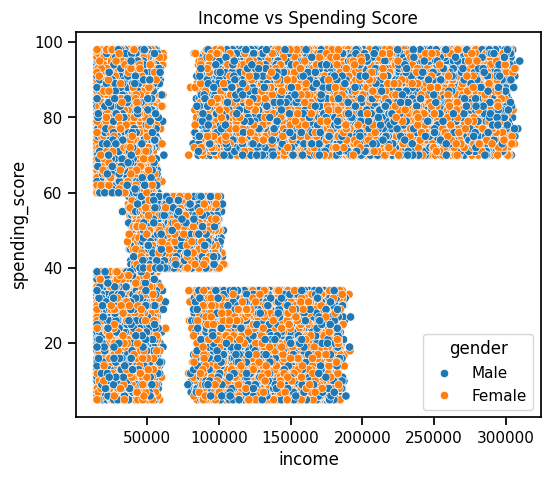

In [ ]:
plt.figure(figsize=(6,5))
sns.scatterplot(
    x="income",
    y="spending_score",
    hue="gender",
    data=df
)
plt.title("Income vs Spending Score")
plt.show()


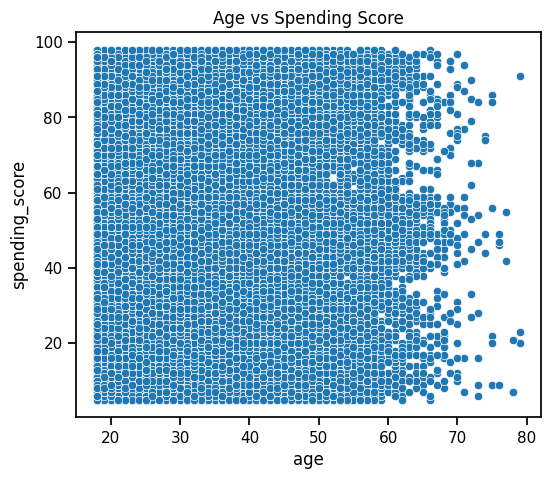

In [ ]:
plt.figure(figsize=(6,5))
sns.scatterplot(
    x="age",
    y="spending_score",
    data=df
)
plt.title("Age vs Spending Score")
plt.show()


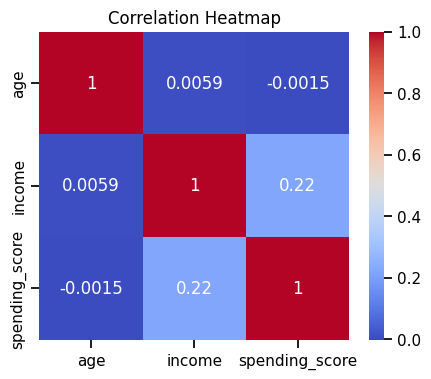

In [ ]:
corr = df[["age", "income", "spending_score"]].corr()
corr
plt.figure(figsize=(5,4))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


In [ ]:
import os
os.makedirs('../data/processed', exist_ok=True)
df.to_csv("../data/processed/mall_customers_clean.csv", index=False)

### EDA Insights

1. Dataset is clean with no missing or duplicate values.
2. Annual income and spending score show visible clustering patterns.
3. Spending behavior is not linearly correlated with income.
4. Gender distribution is balanced and not a dominant factor.
5. Income vs Spending is the strongest feature pair for customer segmentation.
